# F23 MATH 596 Final Project Code

# Credit Card Fraud Analysis and Prediction

## Setup

This section does not need to be expanded or explored.

### Imports

In [1]:
import warnings
from pathlib import Path

# Data Manip
import kagglehub
import pandas as pd

# Backend Code
import credit_card_fraud as ccf

/opt/homebrew/Caskroom/miniconda/base/envs/credit-card-fraud/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Grabbing Data

In [2]:
warnings.filterwarnings("ignore")

In [3]:
# Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/credit-card-fraud-detection-dataset-2023")

print("Path to dataset files:", path)

Path to dataset files: /Users/brandonminer/.cache/kagglehub/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023/versions/1


In [4]:
df = pd.read_csv(
    Path(path+"/creditcard_2023.csv"),
    header = 'infer'
)
df.drop(['id'], axis=1, inplace = True)
df['Class'] = df['Class'].astype(bool)
df.head(5)

target='Class'

ccf.setup(df, 'Class')

In [5]:
print(ccf.get_features())

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


## Exploratory Data Analysis

The first step is the explore our data set to see if we can gain any insight about the data. The obvious first, and only, choice is to look at `Amount`.

### Data Analysis - Histogram of Amount

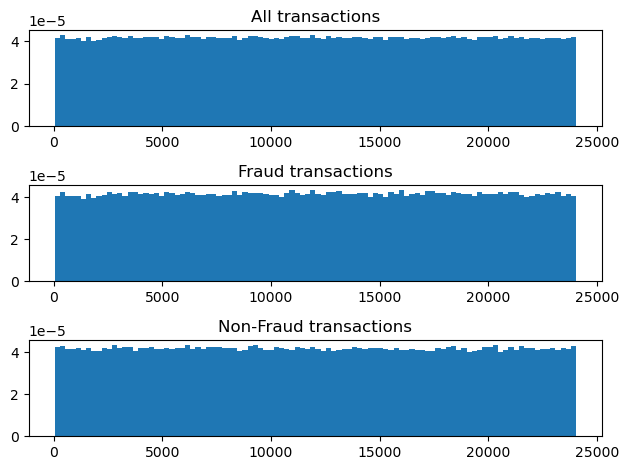

In [6]:
ccf.fraud_hist(100)

From the above histograms, we can see that there is absolutely no association between amount and fraudulent credit card transactions. But doing this for all 28 other features would be time-consuming and impractical.

Something important to note is that this is clearly a toy dataset because the classes are balanced. In reality the proportion of fraud would be as small as $10\%$ copared 

### Data Analysis - Pricipal Component Analysis (PCA)

PCA provides us with multiple benefits:
- Dimensionality Reduction (Model Complexity Reduction)
- Decreased Overfitting
- Handles Multicollinearity

The Scree Plot and Cumulative Explained Variance plots below demonstrate how much each principal component accounts for explained variance.

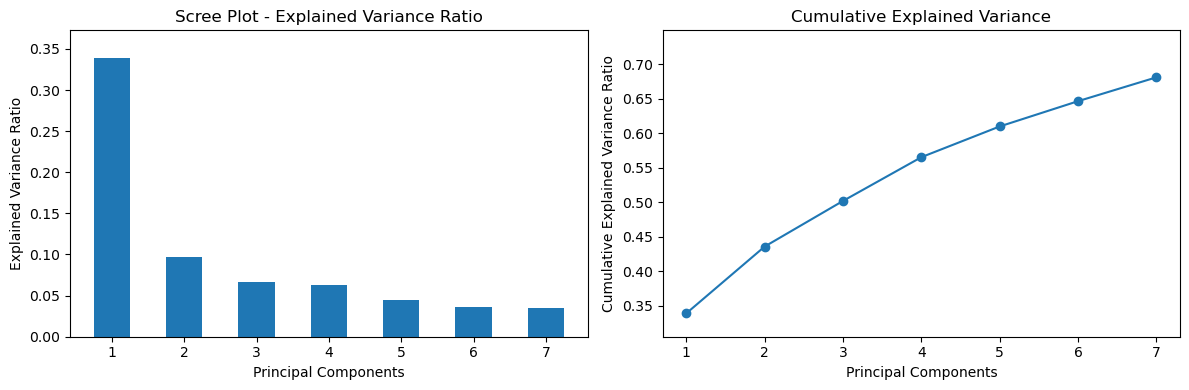

In [7]:
ccf.scree_plt()

The plots show that the 1st principal component(`PC1`) accounts for $33\%$, of the explained variance. All following principal components account for $<11\%$ of explained variance. Because `PC1` is so important, we want to now find which features most greatly correlate to `PC1`. 


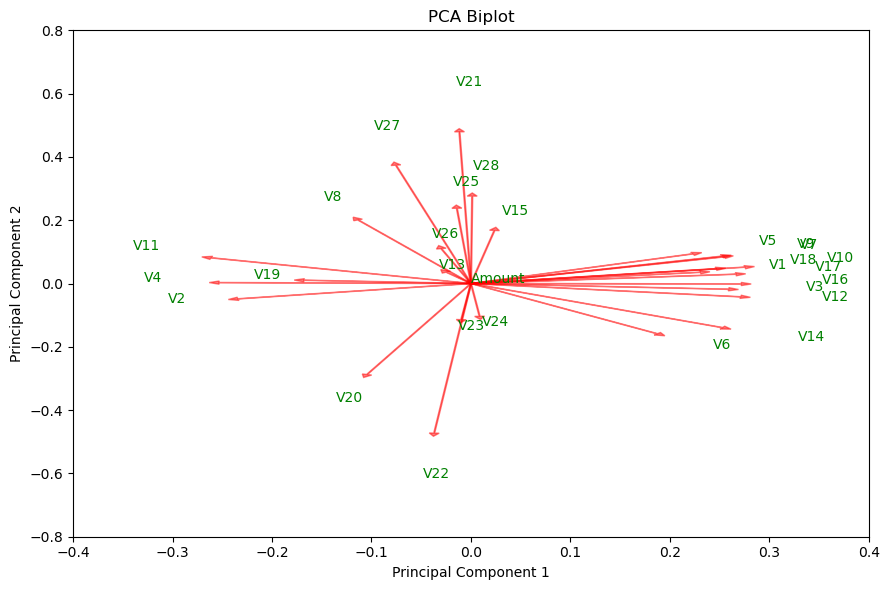

In [8]:
ccf.pca_biplot()

The features which most strongly correlate to `PC1` Are the features whose arrows are the larger along the x-axis. We can also view `PC1` vs. `PC2` by looking at all the data.

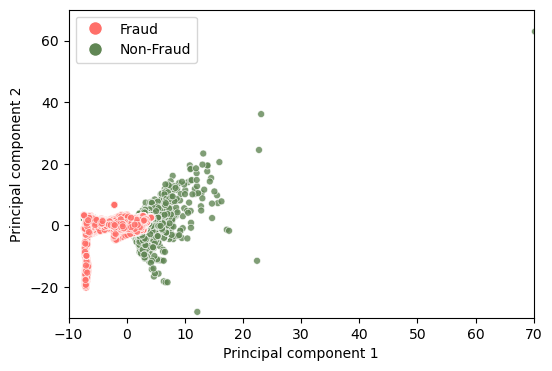

In [9]:
ccf.pca_scatter()

It is interesting to see that just `PC1` and `PC2` *almost* perfectly split the fraud and non-fraud transactions. Based on the PCA Biplot, we select our variables as well as define out target feature column matrix.

In [10]:
V = df[['V1','V2','V3','V4','V5','V6','V7','V9','V10','V11','V12','V14','V16','V17','V18','V19']]
y = df['Class']

## Modeling - Logistic Regression
Because the target feature is binary categorical data, logistic regression is the best first approach. For the purpose of this notebook, it will be our model of choice moving forward. The specs of the model computed are:
- LOSS function = logit
- max iterations = 10,000
- learning rate = 'optimal'

In [31]:
model = ccf.fraud_model(V,y)
ccf.model_accuracy(model)

,Metric,Training Data,Testing Data
0,Accuracy,96.39%,96.38%
1,True Positive Rate (TPR),94.64%,94.60%
2,False Positive Rate (FPR),1.87%,1.84%


We want to avoid false negative predictions at all cost since it is an example of a fraudulent transaction not being flagged. But we don't want to flag every transaction as being fraudulent. To this end, we can select the threshold ($\tau$) value with intent. If the predictied probability of the observation in $\ge \tau$, then we predict that the observation in fraudulent. By default, $\tau=0.5$ because this maximized accuracy. But we can adjust $\tau$ such that we lower overall accuracy and the cost of greatly decreasing false negative rate. 

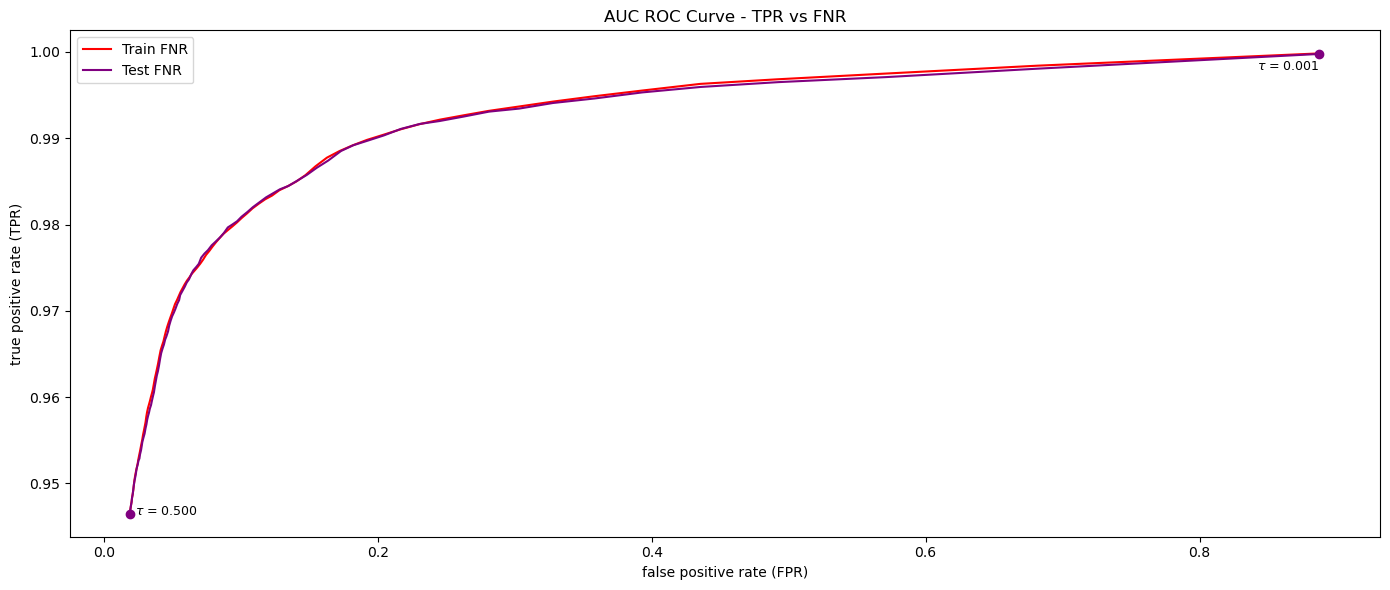

In [12]:
ccf.roc_auc_plot(model)

Since FNR = 1 - TPR, maximizing TPR minimizes FNR. Therefore, we can see that by only subtly decreasing $\tau$, we are able to greatly increase TPR, and thus decrease FNR at only a minor increase in FPR. The specific choice of $\tau$ depends on how large of a FPR we are comfortable. Let's assume that we want a FPR no greater than 2%, then this correlates to a threshold of $\tau\approx 0.484$

In [30]:
ccf.model_accuracy(model, cutoff = 0.484)

,Metric,Training Data,Testing Data
0,Accuracy,96.39%,96.39%
1,True Positive Rate (TPR),94.76%,94.75%
2,False Positive Rate (FPR),1.99%,1.97%


By only slightly decreasing the threshold, we were able to decrease FNR by 0.16%. While this is a minor optimization, a larger tolerance for false positive rate would yield a larger decrease, though FNR decreases slower than FPR increases as the threshold decreases.